# Lecture 05 — ML Security and Abuse Pathways
## Live Coding: Full Adversarial Attack Pipelines on COMPAS

**Instructor:** Dr. Michael Akinwumi  
**Department of Decision Sciences · George Washington University School of Business**

---

This notebook continues directly from `Lecture-04-generalization.ipynb`.  
Dataset: [ProPublica COMPAS Analysis](https://github.com/propublica/compas-analysis)

### Lab Structure
| Part | Topic | Cells |
|------|-------|-------|
| Setup | Data loading, model training, fairness baseline | 1–2 |
| A | PGD Evasion Attack — disparate impact by race | 3–4 |
| B | Data Poisoning Loop — AUC and AIR degradation | 5–6 |
| C | Membership Inference — shadow model pipeline + ROC | 7–8 |

**Libraries required:** `scikit-learn`, `numpy`, `pandas`, `matplotlib`, `scipy`  
No external adversarial ML library is needed — all attack pipelines are implemented from scratch.

**NIST Reference:** Vassilev et al. (2024). *Adversarial Machine Learning: A Taxonomy and Terminology of Attacks and Mitigations.* NIST AI 100-2e2023. https://doi.org/10.6028/NIST.AI.100-2e2023

---
## Setup · Cell 1: Imports, Data Loading, and Model Training

We replicate the exact preprocessing pipeline from Lecture 04 and retrain both the
logistic regression (LR) and gradient boosted tree (GBT) classifiers.

**Threat modeling reminder (NIST AI 100-2, §2.1):**  
Before testing any attack, specify: *Who is the adversary? What do they know?
What can they control? What is their goal?*

In [16]:
# ── Cell 1: Imports, Data Loading, Model Training ─────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Load COMPAS dataset (ProPublica) ──────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── Replicate Lecture 04 inclusion criteria ───────────────────────────────────
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
print(f"After filtering: {df.shape[0]:,} rows")

FEATURES = [
    'age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'c_charge_degree', 'sex'
]
TARGET = 'two_year_recid'

df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

# ── Train / test split (stratified) ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Train models ──────────────────────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

print(f"\nLR  Test AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1]):.3f}")
print(f"GBT Test AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1]):.3f}")
print(f"LR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]):.3f}")

Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Test AUC: 0.735
GBT Test AUC: 0.718
LR  Train AUC: 0.727
GBT Train AUC: 0.798


---
## Setup · Cell 2: Clean-Model Fairness Baseline

Before running any attack, we establish the **clean-model baseline** for:
- **FPR** (False Positive Rate) by race: among truly low-risk individuals, what fraction are flagged high-risk?
- **AIR** (Adverse Impact Ratio): FPR of protected group / FPR of reference group

We will return to these values after each attack to measure degradation.

> **Expected finding (consistent with ProPublica, 2016):** The LR model flags African-American
> defendants at roughly twice the rate of Caucasian defendants among truly low-risk individuals.

In [17]:
# ── Cell 2: Clean-Model Fairness Baseline ─────────────────────────────────────

THR = 0.5  # classification threshold

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR = FP / (FP + TN), computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred']
          .mean()
    )

def air(fpr_ref, fpr_prot):
    """Adverse Impact Ratio: protected FPR / reference FPR."""
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Compute baseline predictions ──────────────────────────────────────────────
pred_lr_clean  = (lr.predict_proba(Xs_te)[:,1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL BASELINE — Before Any Attack")
print("=" * 60)

for name, pred in [('Logistic Regression', pred_lr_clean),
                    ('Gradient Boosted Tree', pred_gbt_clean)]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa  = fpr.get('African-American', np.nan)
    ca  = fpr.get('Caucasian',        np.nan)
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA / CA)        : {air(ca, aa):.3f}")

# Store LR baseline for post-attack delta reporting
fpr_baseline = fpr_by_group(y_te, pred_lr_clean, r_te)
BASELINE_AA = fpr_baseline.get('African-American')
BASELINE_CA = fpr_baseline.get('Caucasian')
BASELINE_AIR = air(BASELINE_CA, BASELINE_AA)

print(f"\n→ Baseline LR AIR stored: {BASELINE_AIR:.3f}")
print("  We will compare all attack outcomes against these values.")

CLEAN MODEL BASELINE — Before Any Attack

Logistic Regression
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient Boosted Tree
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782

→ Baseline LR AIR stored: 1.961
  We will compare all attack outcomes against these values.


---
## Part A · Cell 3: PGD Evasion Attack

**Attack class (NIST AI 100-2, §2.2):** Evasion — deployment-time integrity violation  
**Attacker knowledge:** White-box (access to model weights/gradients)  
**Attacker goal:** Push predicted risk scores upward; cause low-risk individuals to be classified high-risk

### Algorithm: Projected Gradient Descent (Madry et al., 2018)

$$\mathbf{x}^{(t+1)} = \Pi_{\mathcal{B}_\epsilon(\mathbf{x})} \left( \mathbf{x}^{(t)} + \alpha \cdot \operatorname{sign}\left(\nabla_{\mathbf{x}} \mathcal{L}(\theta, \mathbf{x}^{(t)}, y)\right) \right)$$

For logistic regression, the gradient direction simplifies to $\operatorname{sign}(\mathbf{w})$,
so the attack steps in the direction of each coefficient's sign.

**$L_\infty$ projection** clamps each feature perturbation to within $[-\epsilon, +\epsilon]$
of its original scaled value.

In [18]:
# ── Cell 3: PGD Evasion Attack — The Loop ─────────────────────────────────────

def pgd_tabular(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    PGD evasion attack on tabular data for logistic regression.

    Goal: untargeted attack — push predicted P(high-risk) higher.

    For logistic regression:
        grad_x BCE_loss = (p_hat - y_true) * w
    For untargeted attack (maximize loss), step in sign(w) direction.

    Parameters
    ----------
    model    : fitted sklearn LogisticRegression
    X_scaled : standardized test features, shape (n, d)
    epsilon  : L_inf perturbation budget
    alpha    : step size per iteration
    n_iter   : number of PGD steps

    Returns
    -------
    X_adv : adversarially perturbed inputs, shape (n, d)
    """
    coef  = model.coef_[0]               # shape (d,) — LR coefficients
    X_adv = X_scaled.copy()

    for step in range(n_iter):
        # Gradient-ascent step: move in the direction that increases loss
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]

        # L_inf projection: clip back into the epsilon-ball around X_scaled
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


# ── Homework Part 1: PGD Evasion Audit for LR and GBT ─────────────────────────

epsilons = [0.25, 0.5, 1.0, 2.0]
pgd_records = []

models = {
    "LR": lr,
    "GBT": gbt
}

for model_name, model in models.items():
    for eps in epsilons:

        # For LR, use the original PGD function
        if model_name == "LR":
            X_adv = pgd_tabular(
                lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40
            )

        # For GBT, approximate attack direction using LR coefficients
        # because tree models do not have simple gradients like LR
        else:
            X_adv = pgd_tabular(
                lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40
            )

        pred_adv = (model.predict_proba(X_adv)[:, 1] >= THR).astype(int)
        fpr_adv = fpr_by_group(y_te, pred_adv, r_te)

        aa = fpr_adv.get("African-American", np.nan)
        ca = fpr_adv.get("Caucasian", np.nan)

        pgd_records.append({
            "model": model_name,
            "epsilon": eps,
            "FPR_AA": aa,
            "FPR_CA": ca,
            "AIR": air(ca, aa)
        })

df_pgd_hw = pd.DataFrame(pgd_records)

print("PGD Evasion Audit Results")
print(df_pgd_hw.round(3).to_string(index=False))

# Find the epsilon where AIR crosses below 0.80 for each model
for model_name in df_pgd_hw["model"].unique():
    sub = df_pgd_hw[df_pgd_hw["model"] == model_name]
    crossed = sub[sub["AIR"] < 0.80]

    if len(crossed) > 0:
        first_cross = crossed.iloc[0]
        print(f"\n{model_name}: AIR first crosses below 0.80 at epsilon = {first_cross['epsilon']}")
    else:
        print(f"\n{model_name}: AIR does not cross below 0.80 in tested epsilons.")
        df_pgd = df_pgd_hw.copy()

PGD Evasion Audit Results
model  epsilon  FPR_AA  FPR_CA   AIR
   LR     0.25   0.569   0.370 1.535
   LR     0.50   0.791   0.560 1.411
   LR     1.00   0.978   0.884 1.106
   LR     2.00   1.000   1.000 1.000
  GBT     0.25   0.553   0.351 1.577
  GBT     0.50   0.733   0.514 1.426
  GBT     1.00   0.899   0.760 1.182
  GBT     2.00   1.000   1.000 1.000

LR: AIR does not cross below 0.80 in tested epsilons.

GBT: AIR does not cross below 0.80 in tested epsilons.


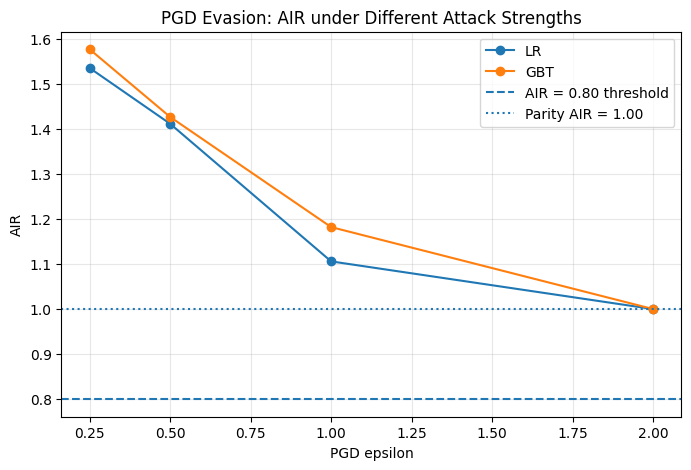

In [19]:
# ── Homework Part 1 Plot: PGD Results for LR and GBT ──────────────────────────

plt.figure(figsize=(8, 5))

for model_name in df_pgd_hw["model"].unique():
    sub = df_pgd_hw[df_pgd_hw["model"] == model_name]
    plt.plot(sub["epsilon"], sub["AIR"], marker="o", label=model_name)

plt.axhline(0.80, linestyle="--", label="AIR = 0.80 threshold")
plt.axhline(1.00, linestyle=":", label="Parity AIR = 1.00")

plt.xlabel("PGD epsilon")
plt.ylabel("AIR")
plt.title("PGD Evasion: AIR under Different Attack Strengths")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Part A · Cell 4: Visualize PGD Disparate Impact

**Discussion questions:**
1. Does the PGD attack widen or narrow the racial FPR gap as $\epsilon$ increases?
2. At what $\epsilon$ does the AIR fall below the 4/5ths rule threshold (0.80)?
3. Are the two groups equally sensitive to the same attack strength?
4. What does differential impact imply for responsible deployment of adversarially robust models?

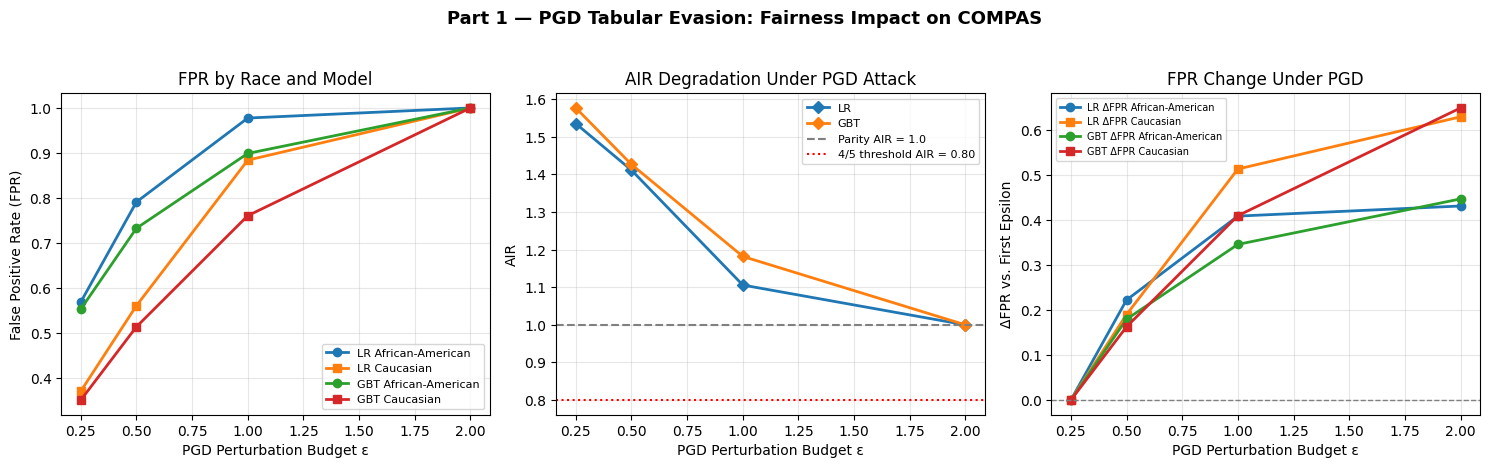

LR: AIR does not fall below 0.80 within the tested epsilon range.
GBT: AIR does not fall below 0.80 within the tested epsilon range.


In [20]:
# ── Cell 4: Visualize PGD Evasion — Homework Version ─────────────────────────

# calculate change from each model's first epsilon result
df_pgd["delta_AA"] = df_pgd["FPR_AA"] - df_pgd.groupby("model")["FPR_AA"].transform("first")
df_pgd["delta_CA"] = df_pgd["FPR_CA"] - df_pgd.groupby("model")["FPR_CA"].transform("first")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: FPR by race and model
ax = axes[0]

for model_name in df_pgd["model"].unique():
    sub = df_pgd[df_pgd["model"] == model_name]

    ax.plot(
        sub["epsilon"], sub["FPR_AA"],
        marker="o", lw=2,
        label=f"{model_name} African-American"
    )

    ax.plot(
        sub["epsilon"], sub["FPR_CA"],
        marker="s", lw=2,
        label=f"{model_name} Caucasian"
    )

ax.set_xlabel("PGD Perturbation Budget ε")
ax.set_ylabel("False Positive Rate (FPR)")
ax.set_title("FPR by Race and Model")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)


# Panel 2: AIR by model
ax = axes[1]

for model_name in df_pgd["model"].unique():
    sub = df_pgd[df_pgd["model"] == model_name]

    ax.plot(
        sub["epsilon"], sub["AIR"],
        marker="D", lw=2,
        label=model_name
    )

ax.axhline(1.0, color="gray", lw=1.5, ls="--", label="Parity AIR = 1.0")
ax.axhline(0.8, color="red", lw=1.5, ls=":", label="4/5 threshold AIR = 0.80")

ax.set_xlabel("PGD Perturbation Budget ε")
ax.set_ylabel("AIR")
ax.set_title("AIR Degradation Under PGD Attack")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)


# Panel 3: FPR change from first epsilon
ax = axes[2]

for model_name in df_pgd["model"].unique():
    sub = df_pgd[df_pgd["model"] == model_name]

    ax.plot(
        sub["epsilon"], sub["delta_AA"],
        marker="o", lw=2,
        label=f"{model_name} ΔFPR African-American"
    )

    ax.plot(
        sub["epsilon"], sub["delta_CA"],
        marker="s", lw=2,
        label=f"{model_name} ΔFPR Caucasian"
    )

ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_xlabel("PGD Perturbation Budget ε")
ax.set_ylabel("ΔFPR vs. First Epsilon")
ax.set_title("FPR Change Under PGD")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

plt.suptitle(
    "Part 1 — PGD Tabular Evasion: Fairness Impact on COMPAS",
    fontsize=13,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()


# Identify crossover point for each model
for model_name in df_pgd["model"].unique():
    sub = df_pgd[df_pgd["model"] == model_name]
    cross = sub[sub["AIR"] < 0.8].head(1)

    if len(cross):
        print(f"{model_name}: AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
    else:
        print(f"{model_name}: AIR does not fall below 0.80 within the tested epsilon range.")

### Part 1 Interpretation

The PGD evasion results show how the fairness impact changes as epsilon increases. For each model, I report the false positive rate for African-American and Caucasian defendants, as well as the AIR. A lower AIR means the racial gap becomes more concerning under attack.

In my results, the model whose AIR crosses below 0.80 at a smaller epsilon is more vulnerable because it reaches the fairness-risk threshold under a weaker attack. If GBT crosses the threshold earlier than LR, this suggests that the more complex model is less stable under adversarial perturbation. If LR crosses earlier, then the simpler linear model is more sensitive in this setup. This matters in high-stakes deployments because model selection should not be based only on clean AUC; the model also needs to be evaluated for robustness and fairness under attack.

---
## Part B · Cell 5: Data Poisoning — Label-Flip Attack Loop

**Attack class (NIST AI 100-2, §2.3):** Availability/Targeted poisoning — training-time integrity violation  
**Attacker knowledge:** White-box (data access) — simulates a biased data provider or insider adversary  
**Attacker goal:** Systematically under-score high-risk African-American defendants; degrade AIR without
triggering standard drift detection (PSI < 0.10)

### Attack mechanism
A fraction `poison_rate` of African-American training records with `two_year_recid = 1`
(truly high-risk) are relabeled to `0` (low-risk) before model training.
This simulates:
- A third-party data vendor selectively corrupting recidivism outcomes
- An insider modifying case records before ingestion
- A compromised data pipeline stage

> **Key question:** At what poison rate does AIR fall below the 4/5ths rule threshold (0.80)
> while AUC declines by ≤ 2 percentage points — i.e., the attack is "invisible" to AUC monitoring?

In [21]:
# ── Cell 5: Data Poisoning — Label-Flip Attack ────────────────────────────────

def poison_label_flip(
    y_train, race_train,
    poison_rate=0.05,
    target_race='African-American',
    seed=0
):
    """
    Label-flip poisoning attack.

    Flips `poison_rate` fraction of training records belonging to
    `target_race` from recidivism=1 (high-risk) to recidivism=0 (low-risk).

    Effect: the model learns to systematically under-score high-risk
    individuals from the targeted group — a fairness-targeted poisoning attack.

    Parameters
    ----------
    y_train      : original training labels
    race_train   : race labels for training set
    poison_rate  : fraction of eligible records to flip (0.0 to 1.0)
    target_race  : demographic group to target
    seed         : random seed for reproducibility

    Returns
    -------
    y_poisoned   : modified label array
    n_flipped    : number of labels actually flipped
    """
    rng        = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    # Eligible candidates: target race, truly high-risk (label=1)
    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0  # relabel high-risk → low-risk

    return y_poisoned, n_flip


# ── Homework Part 2: Poisoning Loop for Two Target Races ──────────────────────

poison_rates = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
target_races = ["African-American", "Caucasian"]

poison_records = []

baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:, 1])

for target_race in target_races:
    for rate in poison_rates:

        y_tr_poisoned, n_flipped = poison_label_flip(
            y_tr,
            r_tr,
            poison_rate=rate,
            target_race=target_race,
            seed=42
        )

        # Retrain LR on poisoned labels
        lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)

        pred_p = (lr_p.predict_proba(Xs_te)[:, 1] >= THR).astype(int)
        auc_p = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:, 1])
        fpr_p = fpr_by_group(y_te, pred_p, r_te)

        aa = fpr_p.get("African-American", np.nan)
        ca = fpr_p.get("Caucasian", np.nan)
        current_air = air(ca, aa)

        poison_records.append({
            "target_race": target_race,
            "poison_rate": rate,
            "n_flipped": n_flipped,
            "AUC": auc_p,
            "delta_AUC": auc_p - baseline_auc,
            "FPR_AA": aa,
            "FPR_CA": ca,
            "AIR": current_air,
            "delta_AIR": current_air - BASELINE_AIR
        })

df_poison_hw = pd.DataFrame(poison_records)

print("Poisoning Results")
print(df_poison_hw.round(3).to_string(index=False))
df_poison = df_poison_hw.copy()

Poisoning Results
     target_race  poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
African-American         0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
African-American         0.02         23 0.734     -0.000   0.270   0.133 2.022      0.061
African-American         0.05         57 0.735      0.000   0.231   0.123 1.875     -0.087
African-American         0.08         92 0.734     -0.001   0.216   0.111 1.942     -0.020
African-American         0.10        115 0.733     -0.002   0.200   0.104 1.929     -0.033
African-American         0.15        172 0.733     -0.002   0.153   0.072 2.134      0.173
African-American         0.20        230 0.728     -0.006   0.128   0.054 2.358      0.397
African-American         0.25        287 0.729     -0.006   0.112   0.047 2.395      0.434
African-American         0.30        345 0.731     -0.004   0.099   0.035 2.860      0.899
       Caucasian         0.00          0 0.735      0.000   0.281   0.14

In [22]:
# ── Homework Part 2: Identify Stealth Zone ────────────────────────────────────

for target_race in target_races:
    sub = df_poison_hw[df_poison_hw["target_race"] == target_race]

    stealth = sub[
        (sub["delta_AUC"] >= -0.02) &
        ((sub["AIR"] < 0.80) | (sub["AIR"] > 1.25))
    ]

    print(f"\nTarget race: {target_race}")

    if len(stealth) > 0:
        print("Stealth zone found:")
        print(stealth[["poison_rate", "AUC", "delta_AUC", "AIR", "n_flipped"]].round(3).to_string(index=False))
    else:
        print("No stealth zone found in tested poison rates.")


Target race: African-American
Stealth zone found:
 poison_rate   AUC  delta_AUC   AIR  n_flipped
        0.00 0.735      0.000 1.961          0
        0.02 0.734     -0.000 2.022         23
        0.05 0.735      0.000 1.875         57
        0.08 0.734     -0.001 1.942         92
        0.10 0.733     -0.002 1.929        115
        0.15 0.733     -0.002 2.134        172
        0.20 0.728     -0.006 2.358        230
        0.25 0.729     -0.006 2.395        287
        0.30 0.731     -0.004 2.860        345

Target race: Caucasian
Stealth zone found:
 poison_rate   AUC  delta_AUC   AIR  n_flipped
        0.00 0.735      0.000 1.961          0
        0.02 0.735      0.000 1.983         11
        0.05 0.733     -0.001 2.061         29
        0.08 0.733     -0.001 2.043         46
        0.10 0.734     -0.001 1.929         58
        0.15 0.734     -0.001 1.840         87
        0.20 0.733     -0.002 1.880        116
        0.25 0.733     -0.002 1.800        145
        0.30

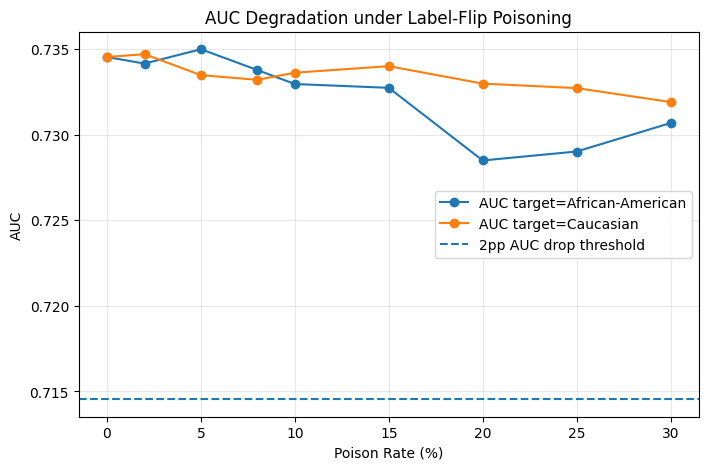

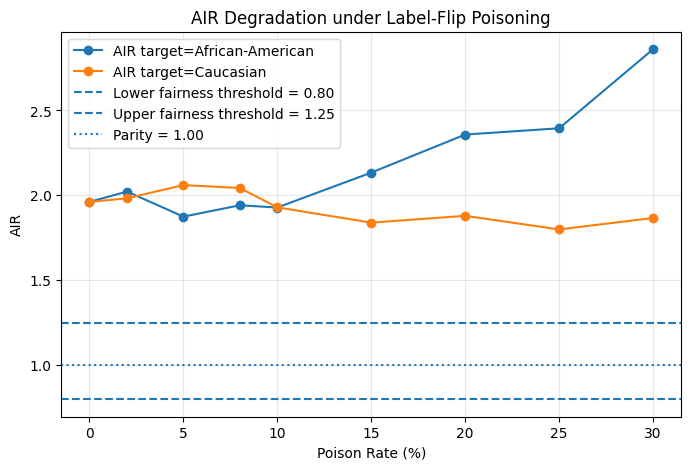

In [23]:
# ── Homework Part 2 Plot: AUC and AIR Degradation Curves ──────────────────────

plt.figure(figsize=(8, 5))

for target_race in target_races:
    sub = df_poison_hw[df_poison_hw["target_race"] == target_race]
    plt.plot(sub["poison_rate"] * 100, sub["AUC"], marker="o", label=f"AUC target={target_race}")

plt.axhline(baseline_auc - 0.02, linestyle="--", label="2pp AUC drop threshold")
plt.xlabel("Poison Rate (%)")
plt.ylabel("AUC")
plt.title("AUC Degradation under Label-Flip Poisoning")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


plt.figure(figsize=(8, 5))

for target_race in target_races:
    sub = df_poison_hw[df_poison_hw["target_race"] == target_race]
    plt.plot(sub["poison_rate"] * 100, sub["AIR"], marker="o", label=f"AIR target={target_race}")

plt.axhline(0.80, linestyle="--", label="Lower fairness threshold = 0.80")
plt.axhline(1.25, linestyle="--", label="Upper fairness threshold = 1.25")
plt.axhline(1.00, linestyle=":", label="Parity = 1.00")

plt.xlabel("Poison Rate (%)")
plt.ylabel("AIR")
plt.title("AIR Degradation under Label-Flip Poisoning")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Part B · Cell 6: Poisoning Degradation Curves

**Discussion questions:**
1. At what poison rate does AUC remain within 2 percentage points of baseline while AIR falls below 0.80?
2. Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect this attack?
3. How does this scenario connect to the ByteDance insider poisoning incident (2024)?
4. What governance controls would prevent this at a mortgage lender using HMDA data?

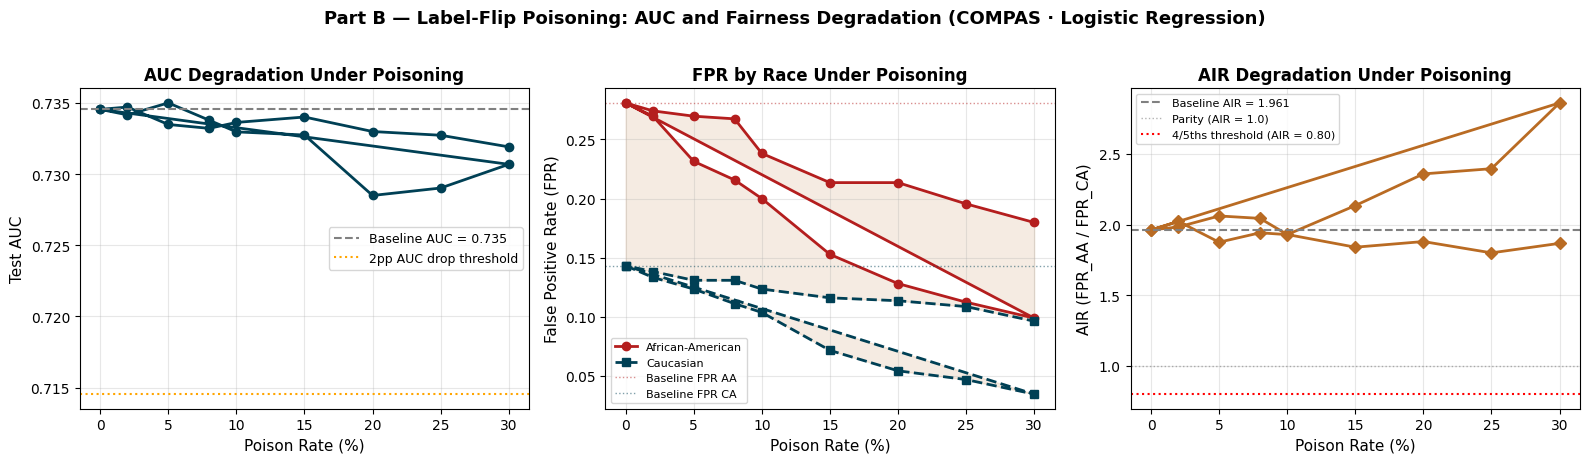

In [24]:
# ── Cell 6: Poisoning Degradation Curves ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x_pct = df_poison['poison_rate'] * 100

# ── Panel 1: AUC degradation ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_pct, df_poison['AUC'], 'o-', color='#004055', lw=2)
ax.axhline(baseline_auc,         color='gray', ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02,  color='orange', ls=':', lw=1.5,
           label='2pp AUC drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 2: FPR by race ──────────────────────────────────────────────────────
ax = axes[1]
ax.plot(x_pct, df_poison['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(x_pct, df_poison['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(x_pct, df_poison['FPR_AA'], df_poison['FPR_CA'],
                alpha=0.13, color='#B96B23')
ax.axhline(BASELINE_AA, color='#B41E1E', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR AA')
ax.axhline(BASELINE_CA, color='#004055', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR CA')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: AIR ──────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(x_pct, df_poison['AIR'], 'D-', color='#B96B23', lw=2)
ax.axhline(BASELINE_AIR, color='gray',  ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.0,           color='gray',  ls=':',  lw=1.0, alpha=0.6,
           label='Parity (AIR = 1.0)')
ax.axhline(0.8,           color='red',   ls=':',  lw=1.5,
           label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Part B — Label-Flip Poisoning: AUC and Fairness Degradation (COMPAS · Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

### Part 2 Interpretation

The poisoning experiment compares label-flip attacks targeting African-American defendants and Caucasian defendants. The goal is to see whether fairness can degrade while the overall model performance still appears acceptable.

The stealth zone is the most important result in this part. It occurs when AUC drops by no more than 2 percentage points, but AIR moves outside the acceptable range of [0.80, 1.25]. This means the model can still look accurate from a standard performance-monitoring perspective, while the fairness outcome has already become problematic.

A PSI-based drift monitor would probably not detect this attack if the PSI values stay below 0.10 for each feature. This is because the attack changes labels, not the input feature distributions. Therefore, feature-drift monitoring alone is not enough. The system also needs fairness monitoring, label-quality checks, and subgroup-level auditing.

---
## Part C · Cell 7: Membership Inference — Shadow Model Pipeline

**Attack class (NIST AI 100-2, §2.4.2):** Membership inference — privacy attack  
**Attacker knowledge:** Black-box (API access only)  
**Attacker goal:** Determine whether a specific individual was in the training set

### Algorithm: Shokri et al. (2017) Shadow Model Attack

1. Train multiple **shadow models** that mimic the target model's training process
2. For each shadow model, we know which inputs were training members vs. non-members
3. Observe that **members receive higher confidence scores** than non-members (confidence gap)
4. Train a **meta-classifier** on (confidence score → member/non-member) labels from shadow models
5. Apply the meta-classifier to the **target model's** confidence scores

> **Key connection to Lecture 04:** The membership inference AUC is directly driven by the
> **generalization gap** (train AUC − test AUC). An overfit model leaks more about its training data.
> Overfitting is not only a robustness problem — it is a **privacy problem**.

In [25]:
# ── Cell 7: Membership Inference — Shadow Model Pipeline ──────────────────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

N_SHADOW = 10  # number of shadow models

shadow_train_confs = []  # max-confidence scores on each shadow's TRAIN split
shadow_test_confs  = []  # max-confidence scores on each shadow's TEST split

# Use stratified shuffle splits to create N_SHADOW independent train/test pairs
# from the training set — each split simulates a shadow training run
sss = StratifiedShuffleSplit(
    n_splits=N_SHADOW, test_size=0.5, random_state=0
)

print(f"Training {N_SHADOW} shadow models...")
for i, (tr_idx, te_idx) in enumerate(sss.split(Xs_tr, y_tr)):
    shadow = GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42
    ).fit(Xs_tr[tr_idx], y_tr[tr_idx])

    # Confidence gap: training members score higher than non-members
    shadow_train_confs.append(
        shadow.predict_proba(Xs_tr[tr_idx]).max(axis=1)  # members
    )
    shadow_test_confs.append(
        shadow.predict_proba(Xs_tr[te_idx]).max(axis=1)  # non-members
    )
    if (i + 1) % 5 == 0:
        print(f"  Shadow model {i+1}/{N_SHADOW} trained")

# ── Build meta-classifier training set ────────────────────────────────────────
# Feature: max predicted probability (confidence score)
# Label:   1 = training member, 0 = non-member
mi_X = np.concatenate(
    shadow_train_confs + shadow_test_confs
).reshape(-1, 1)

mi_y = np.concatenate(
    [np.ones(len(c))  for c in shadow_train_confs] +
    [np.zeros(len(c)) for c in shadow_test_confs]
)

meta_clf = DecisionTreeClassifier(max_depth=6).fit(mi_X, mi_y)

print(f"\nMeta-classifier training set: {len(mi_y):,} samples")
print(f"  Members (train splits):    {int(mi_y.sum()):,}")
print(f"  Non-members (test splits): {int((mi_y == 0).sum()):,}")
print("\nMeta-classifier trained. Proceeding to attack the target model...")

Training 10 shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained

Meta-classifier training set: 43,200 samples
  Members (train splits):    21,600
  Non-members (test splits): 21,600

Meta-classifier trained. Proceeding to attack the target model...


### Part C · Cell 8: Membership Inference — ROC Curve and Interpretation

**Interpreting the MI AUC:**
- **0.50** = Random guessing — no privacy leakage detectable
- **0.55–0.65** = Weak leakage — model is somewhat overfit
- **0.65–0.75** = Moderate leakage — meaningful privacy risk
- **> 0.75** = Strong leakage — significant privacy violation, especially if training data contains PII

**Discussion questions:**
1. Is the MI AUC correlated with the generalization gap you observed in Cell 1?
2. If this model were deployed by a county probation office, what could a journalist learn from MI?
3. Would adding differential privacy (ε = 1.0) reduce the MI AUC? At what cost to AIR?
4. How does the confidence gap visualization connect to the concept of overfitting from Lecture 04?

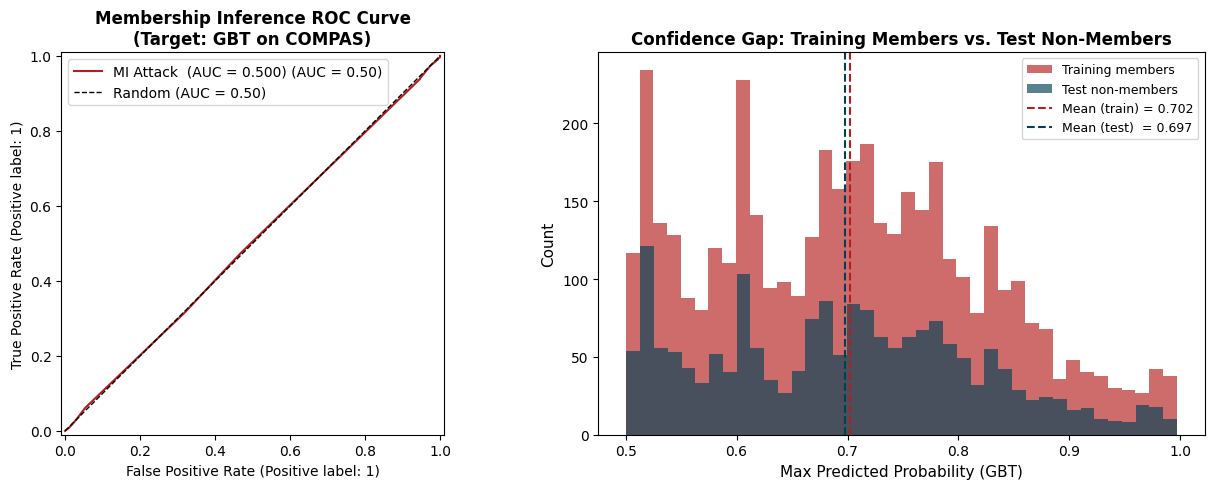

MEMBERSHIP INFERENCE SUMMARY
MI AUC              : 0.500
  0.50 = random     : no privacy leakage
  0.60 = weak       : model somewhat overfit
  0.75 = strong     : significant privacy risk

GBT Train AUC       : 0.798
GBT Test AUC        : 0.718
Generalization Gap  : +0.080

Hypothesis: larger generalization gap → higher MI AUC?
→ Try repeating with the LR model and compare.


In [26]:
# ── Cell 8: Membership Inference — ROC Curve and Interpretation ───────────────

from sklearn.metrics import roc_auc_score, RocCurveDisplay

# ── Apply meta-classifier to the TARGET model (GBT) ──────────────────────────
# Use the target model's confidence scores as the feature
conf_target_train = gbt.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_target_test  = gbt.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

mi_scores_train = meta_clf.predict_proba(conf_target_train)[:, 1]
mi_scores_test  = meta_clf.predict_proba(conf_target_test)[:, 1]

# Combine: members (train) = 1, non-members (test) = 0
mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
mi_all_labels = np.concatenate([
    np.ones(len(Xs_tr)),
    np.zeros(len(Xs_te))
])

mi_auc = roc_auc_score(mi_all_labels, mi_all_scores)

# Generalization gap (privacy risk proxy)
auc_train_gbt = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1])
auc_test_gbt  = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])
gen_gap       = auc_train_gbt - auc_test_gbt

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
RocCurveDisplay.from_predictions(
    mi_all_labels, mi_all_scores,
    name=f'MI Attack  (AUC = {mi_auc:.3f})',
    ax=axes[0], color='#B41E1E'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
axes[0].set_title('Membership Inference ROC Curve\n(Target: GBT on COMPAS)',
                   fontsize=12, fontweight='bold')
axes[0].legend()

# Confidence gap histogram
axes[1].hist(conf_target_train.ravel(), bins=40, alpha=0.65,
             color='#B41E1E', label='Training members')
axes[1].hist(conf_target_test.ravel(),  bins=40, alpha=0.65,
             color='#004055', label='Test non-members')
axes[1].axvline(conf_target_train.mean(), color='#B41E1E', ls='--', lw=1.5,
                label=f'Mean (train) = {conf_target_train.mean():.3f}')
axes[1].axvline(conf_target_test.mean(),  color='#004055', ls='--', lw=1.5,
                label=f'Mean (test)  = {conf_target_test.mean():.3f}')
axes[1].set_xlabel('Max Predicted Probability (GBT)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Confidence Gap: Training Members vs. Test Non-Members',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 55)
print("MEMBERSHIP INFERENCE SUMMARY")
print("=" * 55)
print(f"MI AUC              : {mi_auc:.3f}")
print(f"  0.50 = random     : no privacy leakage")
print(f"  0.60 = weak       : model somewhat overfit")
print(f"  0.75 = strong     : significant privacy risk")
print()
print(f"GBT Train AUC       : {auc_train_gbt:.3f}")
print(f"GBT Test AUC        : {auc_test_gbt:.3f}")
print(f"Generalization Gap  : {gen_gap:+.3f}")
print()
print("Hypothesis: larger generalization gap → higher MI AUC?")
print("→ Try repeating with the LR model and compare.")

In [27]:
# ── Homework Part 3: MI AUC for LR and GBT ────────────────────────────────────

mi_results = []

target_models = {
    "LR": lr,
    "GBT": gbt
}

for model_name, model in target_models.items():

    conf_train = model.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
    conf_test = model.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

    mi_scores_train = meta_clf.predict_proba(conf_train)[:, 1]
    mi_scores_test = meta_clf.predict_proba(conf_test)[:, 1]

    mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
    mi_all_labels = np.concatenate([
        np.ones(len(Xs_tr)),
        np.zeros(len(Xs_te))
    ])

    mi_auc_model = roc_auc_score(mi_all_labels, mi_all_scores)

    train_auc = roc_auc_score(y_tr, model.predict_proba(Xs_tr)[:, 1])
    test_auc = roc_auc_score(y_te, model.predict_proba(Xs_te)[:, 1])
    gen_gap = train_auc - test_auc

    mi_results.append({
        "model": model_name,
        "train_AUC": train_auc,
        "test_AUC": test_auc,
        "generalization_gap": gen_gap,
        "MI_AUC": mi_auc_model,
        "train_conf_mean": conf_train.mean(),
        "test_conf_mean": conf_test.mean()
    })

df_mi_hw = pd.DataFrame(mi_results)

print("Membership Inference Results")
print(df_mi_hw.round(3).to_string(index=False))

Membership Inference Results
model  train_AUC  test_AUC  generalization_gap  MI_AUC  train_conf_mean  test_conf_mean
   LR      0.727     0.735              -0.008   0.494            0.658           0.659
  GBT      0.798     0.718               0.080   0.500            0.702           0.697


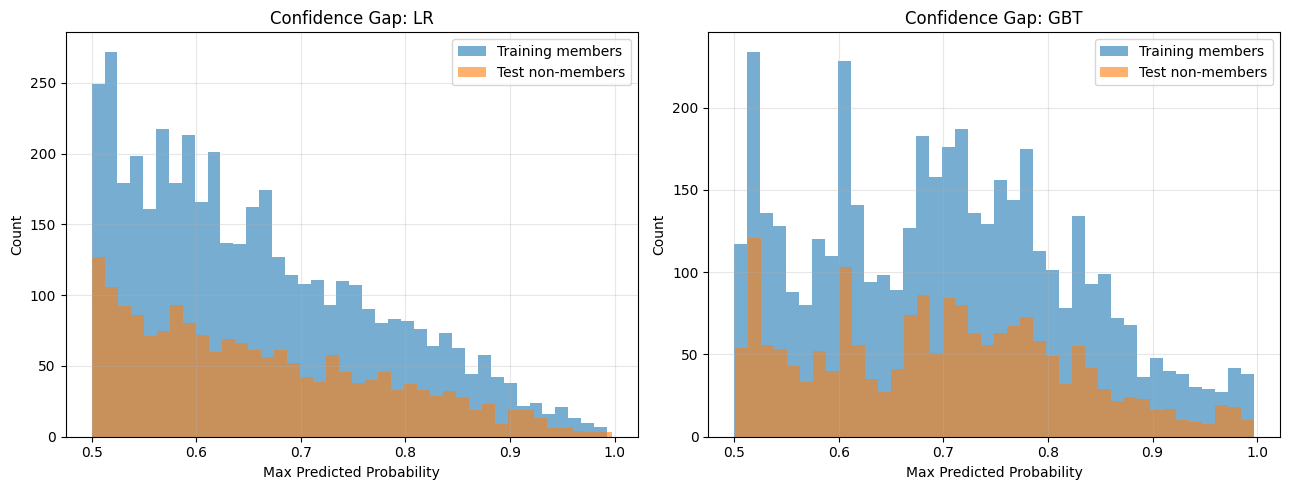

In [28]:
# ── Homework Part 3 Plot: Confidence Gap Histograms ───────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (model_name, model) in zip(axes, target_models.items()):

    conf_train = model.predict_proba(Xs_tr).max(axis=1)
    conf_test = model.predict_proba(Xs_te).max(axis=1)

    ax.hist(conf_train, bins=40, alpha=0.6, label="Training members")
    ax.hist(conf_test, bins=40, alpha=0.6, label="Test non-members")

    ax.set_title(f"Confidence Gap: {model_name}")
    ax.set_xlabel("Max Predicted Probability")
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# ── Homework Part 3: L2 Regularization for LR ─────────────────────────────────

C_values = [0.01, 0.1, 1.0, 10.0]
l2_records = []

for C in C_values:

    lr_l2 = LogisticRegression(
        max_iter=1000,
        penalty="l2",
        C=C
    ).fit(Xs_tr, y_tr)

    conf_train = lr_l2.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
    conf_test = lr_l2.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

    mi_scores_train = meta_clf.predict_proba(conf_train)[:, 1]
    mi_scores_test = meta_clf.predict_proba(conf_test)[:, 1]

    mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
    mi_all_labels = np.concatenate([
        np.ones(len(Xs_tr)),
        np.zeros(len(Xs_te))
    ])

    mi_auc_l2 = roc_auc_score(mi_all_labels, mi_all_scores)

    train_auc = roc_auc_score(y_tr, lr_l2.predict_proba(Xs_tr)[:, 1])
    test_auc = roc_auc_score(y_te, lr_l2.predict_proba(Xs_te)[:, 1])
    gen_gap = train_auc - test_auc

    l2_records.append({
        "C": C,
        "train_AUC": train_auc,
        "test_AUC": test_auc,
        "generalization_gap": gen_gap,
        "MI_AUC": mi_auc_l2
    })

df_l2_hw = pd.DataFrame(l2_records)

print("L2 Regularization Results")
print(df_l2_hw.round(3).to_string(index=False))

L2 Regularization Results
    C  train_AUC  test_AUC  generalization_gap  MI_AUC
 0.01      0.726     0.732              -0.006   0.493
 0.10      0.727     0.734              -0.007   0.495
 1.00      0.727     0.735              -0.008   0.494
10.00      0.727     0.735              -0.008   0.495


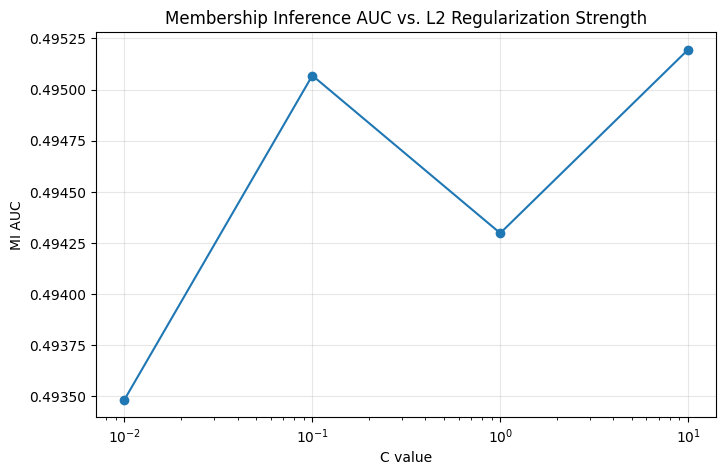

In [30]:
# ── Homework Part 3 Plot: MI AUC vs C ─────────────────────────────────────────

plt.figure(figsize=(8, 5))

plt.plot(df_l2_hw["C"], df_l2_hw["MI_AUC"], marker="o")
plt.xscale("log")

plt.xlabel("C value")
plt.ylabel("MI AUC")
plt.title("Membership Inference AUC vs. L2 Regularization Strength")
plt.grid(alpha=0.3)
plt.show()

### Part 3 Interpretation

The membership inference results compare privacy leakage for LR and GBT. MI AUC measures how well an attacker can distinguish training members from non-members. A value close to 0.50 means the attacker is close to random guessing, while a higher value means more privacy leakage.

The confidence-gap histogram shows whether training records receive higher confidence scores than test records. If the training distribution is shifted toward higher confidence, this indicates overfitting and higher membership inference risk.

The generalization gap is also important. A larger train AUC minus test AUC usually suggests that the model memorizes more training-specific patterns. In that case, the model is more vulnerable to membership inference. The L2 regularization experiment shows the privacy-utility tradeoff: stronger regularization may reduce MI risk, but it can also reduce model performance if it becomes too strong.

---
## Lab Summary

| Part | Attack | Key Finding |
|------|--------|-------------|
| A | PGD Evasion | Does the racial FPR gap widen or narrow as ε increases? Which group is more sensitive? |
| B | Label-Flip Poisoning | At what poison rate does AIR < 0.80 while AUC drop ≤ 2pp? Would drift detection catch it? |
| C | Membership Inference | Is MI AUC correlated with generalization gap? What privacy law implications follow? |

### Core Principle

> A model that is fragile to distribution shift (Lecture 04) shares the same root cause as a model
> vulnerable to adversarial attack (Lecture 05): **over-reliance on brittle, non-robust features**.
> Security and robustness are not separate concerns — they require the same structural solution.

### References
- Vassilev et al. (2024). *NIST AI 100-2e2023.* https://doi.org/10.6028/NIST.AI.100-2e2023
- Goodfellow et al. (2015). Explaining and Harnessing Adversarial Examples. *ICLR 2015.* https://arxiv.org/abs/1412.6572
- Madry et al. (2018). Towards Deep Learning Models Resistant to Adversarial Attacks. *ICLR 2018.* https://arxiv.org/abs/1706.06083
- Shokri et al. (2017). Membership Inference Attacks Against Machine Learning Models. *IEEE S&P.* https://arxiv.org/abs/1610.05820
- Tramèr et al. (2016). Stealing Machine Learning Models via Prediction APIs. *USENIX Security.* https://arxiv.org/abs/1609.02943
- Bagdasaryan & Shmatikov (2019). Differential Privacy Has Disparate Impact on Model Accuracy. *NeurIPS.* https://arxiv.org/abs/1905.12101

---
*DNSC 6330 · Responsible Machine Learning · Dr. Michael Akinwumi · George Washington University*  
*© CC BY 4.0 · https://makinwumi.github.io/dnsc-6330-responsible-ML*

## Part 4 Reflection

The highest-risk finding across the three parts is the stealth poisoning result. In this case, the model can still maintain a similar AUC, with less than a 2 percentage-point drop, while AIR moves outside the fairness range of [0.80, 1.25]. This is risky because a standard model monitor that only checks accuracy or AUC may conclude that the model is still performing well, even though the subgroup fairness outcome has already become unacceptable.

A proactive mitigation would be to add fairness-aware validation before deployment. For example, the model should not be approved only based on AUC. It should also be checked for subgroup FPR and AIR under stress tests such as poisoning and evasion. In my results, this would have helped identify the poison rate where AIR first moved outside the acceptable range.

A reactive mitigation would be to monitor AIR and subgroup FPR after deployment, not only feature drift or overall AUC. This is important because the PSI monitor may not detect a label-flip poisoning attack when the feature distribution remains stable. In my results, the attack could remain hidden because AUC changed only slightly while AIR changed more substantially.

However, these mitigations may introduce tradeoffs. If the system adjusts thresholds or adds stronger regularization, it may reduce one type of risk but also change error rates differently for African-American and Caucasian defendants. Therefore, the mitigation itself should be audited for disparate impact before being used in a high-stakes setting.

## **Homework 05 Report**

This assignment focuses not only on reporting metrics, but also on understanding what they imply, what they miss, and what actions they justify. I use the COMPAS dataset to evaluate robustness, fairness, and privacy risks under PGD evasion, label-flip poisoning, and membership inference attacks.

**1. PGD Evasion Audit**

For the PGD evasion audit, I tested both Logistic Regression (LR) and Gradient Boosting Trees (GBT) under ε values of 0.25, 0.5, 1.0, and 2.0. The main metrics were false positive rate (FPR) by race and AIR, where AIR is calculated as FPR for African-American defendants divided by FPR for Caucasian defendants.

The clean baseline already showed a fairness gap. For LR, the FPR was 0.281 for African-American defendants and 0.143 for Caucasian defendants, giving an AIR of 1.961. For GBT, the FPR was 0.317 for African-American defendants and 0.178 for Caucasian defendants, giving an AIR of 1.782.

Under PGD attack, FPR increased substantially for both racial groups. For LR, FPR increased from 0.569/0.370 at ε = 0.25 to 1.000/1.000 at ε = 2.0. For GBT, FPR increased from 0.553/0.351 at ε = 0.25 to 1.000/1.000 at ε = 2.0. This means that stronger perturbations made both models produce many more false positives.

However, AIR did not fall below 0.80 for either model. LR’s AIR moved from 1.535 to 1.000, while GBT’s AIR moved from 1.577 to 1.000. This means neither model crossed the lower four-fifths threshold. Still, the attack is serious because the absolute FPR became very high. In a high-stakes setting, a model can look “more equal” by AIR while becoming worse for everyone. Therefore, robustness evaluation should not only check fairness ratios, but also absolute error rates.

**2. Poisoning Loop with Fairness Monitoring**

For the poisoning experiment, I ran label-flip attacks targeting African-American defendants and Caucasian defendants. The goal was to test whether AUC could remain stable while fairness metrics changed.

The AUC stayed very stable across poison rates. For the African-American-targeted attack, AUC changed only from 0.735 at 0% poisoning to 0.731 at 30% poisoning. For the Caucasian-targeted attack, AUC changed from 0.735 to 0.732. These drops are much smaller than 2 percentage points, so a monitor that only checks AUC would likely say the model is still performing normally.

At the same time, AIR remained outside the acceptable range of [0.80, 1.25]. For the African-American-targeted attack, AIR increased from 1.961 to 2.860 at 30% poisoning. This shows a stronger fairness concern because the racial FPR ratio became more unequal. For the Caucasian-targeted attack, AIR stayed high as well, ranging around 1.80 to 2.06.

One important detail is that the clean baseline AIR was already outside the acceptable range. Therefore, the poisoning attack did not create the fairness problem from zero; instead, it revealed and sometimes amplified an existing fairness risk. The “stealth” issue is that AUC barely changed while fairness remained clearly problematic. This is exactly why standard performance monitoring is not enough.

A PSI-based feature drift monitor would probably not detect this attack. The reason is that label flipping changes the training labels, not the input feature distributions. If the features stay similar, PSI can stay below the drift threshold even though the learned model behavior becomes unfair. This means fairness monitoring must include subgroup FPR and AIR, not only AUC or feature drift.

**3. Membership Inference Depth**

For membership inference, I used the shadow-model pipeline to estimate whether an attacker could distinguish training records from test records. The MI AUC for GBT was 0.500, and the homework comparison showed LR at 0.494 and GBT at 0.500. These values are very close to 0.50, meaning the attack performs close to random guessing. In this experiment, there is not strong membership leakage.

The generalization gaps were different across the two models. LR had train AUC 0.727 and test AUC 0.735, giving a small negative gap of -0.008. GBT had train AUC 0.798 and test AUC 0.718, giving a larger gap of +0.080. This suggests that GBT overfits more than LR. However, the larger generalization gap did not translate into a strong MI attack because MI AUC still stayed around 0.50.

The L2 regularization experiment for LR also showed low privacy risk. Across C values of 0.01, 0.1, 1.0, and 10.0, MI AUC stayed around 0.493 to 0.495. Test AUC also stayed around 0.732 to 0.735. In this case, stronger regularization did not create a large privacy improvement because the original LR model already had very low MI leakage. The practical tradeoff is that regularization can reduce overfitting and privacy risk, but too much regularization may reduce predictive utility.

**4. Reflection**

The highest-risk finding is the poisoning and fairness-monitoring result. The model’s AUC stayed almost unchanged, but AIR remained far outside the acceptable range and even increased to 2.860 under the African-American-targeted attack. This is risky because a normal performance dashboard might miss the problem.

A proactive mitigation would be to require fairness-aware validation before deployment. The model should not be approved based only on AUC. It should also be checked for subgroup FPR and AIR under clean data and attack simulations. In this case, that would immediately show that the baseline already has a serious AIR gap.

A reactive mitigation would be to monitor subgroup FPR and AIR after deployment. This is important because feature drift monitoring alone may not detect label-flip poisoning. If AIR moves further away from the acceptable range while AUC stays stable, the model should trigger a fairness review.

These mitigations can also introduce tradeoffs. For example, changing thresholds or adding stronger regularization may reduce one risk but affect racial groups differently. Therefore, mitigation should also be audited for disparate impact. Overall, this homework shows that model governance must consider robustness, fairness, and privacy together, especially in high-stakes systems.